# Universidad Anahuac Puebla
## Maestría en Big Data e Inteligencia Artificial
### Matería: Machine Learning
#### Profesor: Dr. Paulo Daniel Vázquez Mora
#### Alumno: Miguel Ángel Morán Flores
**27/04/2026**
___

# Problema del lago congelado (4x4, 8x8 y 16x16)

Este problema plantea que un agente debe cruzar un lago congelado, desde un extremo del mismo al otro lado. En el camino puede encontrar alguno orificios en el hielo los cuales le pueden hace caer. Utilizando el algoritmo *Q-Learning* el agente debe encontrar el camino mas óptimo. El punto de inicio se representa con *S* y por el otro lado la meta se identifica con la letra *G*.

## Configuración del entorno


In [1]:
# Importación de librerías
import numpy as np
import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import random
import matplotlib.pyplot as plt

___
# Sección 1: Visualización 4x4

In [2]:
# Crear el entorno del lago congelado
entorno = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)

In [3]:
# Definir los estados y acciones de nuestro ambiente
no_estados = entorno.observation_space.n
no_acciones = entorno.action_space.n

In [4]:
print(f'El número de estados es: {no_estados}')
print(f'El número de acciones es: {no_acciones}')

El número de estados es: 16
El número de acciones es: 4


## 1.1 Definir e inicial la matriz Q


La matriz Q almacena el valor de la función Q (de la mayor ganancia o recompensa al desplazamiento del agente).

In [5]:
# Definición e inicialización de la matriz Q
matriz_Q = np.zeros((no_estados, no_acciones))
print(matriz_Q)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## 1.2 Definición de los hiperparametros


Para que el algoritmo Q-Learning pueda entrenarse es necesario establecer ciertos parámetros, los cuales e listan a continuación:
- *learning_rate*: Determina cuanto de la información aprendida se mantiene en contexto. Su valor esta dado entre 0-1. Por ejemplo, si indico que la tasa es de 1, entonces solo considear la nueva información.
- *discount_factor*: Determina la importancia de la recompensa futura. Un valor 0 hace que el agente no vea mas allá de la recompensa actual.
- *epsilon*: la probabilidad de que el agente explore el entorno de manera aleatoria.
- *max_episodes*: El número total de veces en que el agente intenta resolver el problema.
- *max_steps_per_episode*: El número máximo de acciones que el agente puede tomar en un episodio.

In [6]:
# Definir los hiperpáremetros
tasa_aprendizaje = 0.8
factor_descuento = 0.8
epsilon = 1
max_episodios = 5000
max_pasos_por_episodio = 100


In [7]:
# Definición de recompensas por episodio
recompensa_por_episodio = []

## 1.3 Entrenamiento

In [8]:
# Hiperparámetros de epsilon
min_epsilon = 0.01
epsilon_decay_rate = 0.0001

# Definición del ciclo de entrenamiento
for episodio in range(max_episodios):
    # Resetear el entorno
    estado, info = entorno.reset()
    terminado = False
    inconcluso = False
    recompensa_actual = 0

    for paso in range(max_pasos_por_episodio):
      # 1. Elección de la acción
      if random.uniform(0, 1) < epsilon:
        accion = entorno.action_space.sample() # Acción aleatora
      else:
        accion = np.argmax(matriz_Q[estado, :]) # Acción basada en el valor conocido

      # 2. Ejecución de la acción y recepción de la recompensa y actualización del estado
      nuevo_estado, recompensa, terminado, inconcluso, info = entorno.step(accion)

      # 3. Actualizar el valor de la funcion Q(s, a) en la matriz Q con respecto de los nuevos valores
      matriz_Q[estado, accion] = matriz_Q[estado, accion] + tasa_aprendizaje * (recompensa + factor_descuento * np.max(matriz_Q[nuevo_estado, :]) - matriz_Q[estado, accion])
      estado = nuevo_estado
      recompensa_actual += recompensa
      # Verificación de no excedente de pasos
      if terminado == True:
        break

    # Decremento de epsilon
    epsilon = max(min_epsilon, epsilon - epsilon_decay_rate)
    # Almacenamiento de las recompensas por episodio
    recompensa_por_episodio.append(recompensa_actual)

    # Retroalimentación del avance de los episodios
    if episodio % 1000 == 0:
      print(f'Episodio: {episodio}, recompensa promedio: {np.mean(recompensa_por_episodio[-100:])}, epsilon: {epsilon}')
entorno.close()
print('Entrenando terminado')



Episodio: 0, recompensa promedio: 0.0, epsilon: 0.9999
Episodio: 1000, recompensa promedio: 0.06, epsilon: 0.899900000000011
Episodio: 2000, recompensa promedio: 0.1, epsilon: 0.799900000000022
Episodio: 3000, recompensa promedio: 0.15, epsilon: 0.699900000000033
Episodio: 4000, recompensa promedio: 0.32, epsilon: 0.5999000000000441
Entrenando terminado


## 1.4 Evaluación del agente entrenado

Para evaluar el entrenamiendo del agente, es necesario ejecutar algunos episodios adicionales pero ahora empleando las politicas ya calculadas (matriz_Q) sin necesidad de explorar nuevamente el espacio de estados.

In [9]:
# Evaluando el rendimiento del agente
episodios_prueba = 100
exitos = 0

# Recrear el entorno para evaluación
entorno_eval = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')

print("\nEvaluando el desempeño del agente")

for episodio in range(episodios_prueba):
  estado, info = entorno_eval.reset()
  terminado = False
  inconcluso = False

  for paso in range(max_pasos_por_episodio):
    accion = np.argmax(matriz_Q[estado, :])
    nuevo_estado, recompensa, terminado, inconcluso, info = entorno_eval.step(accion)
    estado = nuevo_estado
    if terminado and recompensa == 1:
      exitos += 1
      break
    elif terminado or inconcluso:
      break
  entorno_eval.close()

tasa_exito = (exitos / episodios_prueba) * 100
print(f'Tasa de éxito del agente: {tasa_exito}%')


Evaluando el desempeño del agente
Tasa de éxito del agente: 100.0%


## 1.5 **Ejecución de un episodio de prueba:** 
Programe una función que ejecute un único episodio donde el agente actúe de manera 100% voraz (greedy), es decir, utilizando siempre la mejor acción dictada por la matriz Q.

In [10]:
def ejecutar_episodio_greedy(entorno, matriz_Q):
    """
    Ejecuta un único episodio donde el agente siempre elige la acción 
    con el valor más alto en la matriz Q para el estado actual.
    """
    estado, info = entorno.reset()
    terminado = False
    inconcluso = False
    trayectoria = [estado] # Guardamos los estados para la Fase de visualización
    recompensa_total = 0

    while not (terminado or inconcluso):
        # Selección voraz (Greedy): tomamos el índice del valor máximo
        accion = np.argmax(matriz_Q[estado, :])
        
        # Aplicar la acción al entorno
        estado, recompensa, terminado, inconcluso, info = entorno.step(accion)
        
        trayectoria.append(estado)
        recompensa_total += recompensa

    return trayectoria, recompensa_total

In [11]:
# Ejecución de la prueba técnica
# Asegúrate de usar el entorno 4x4 original
trayectoria_final, exito = ejecutar_episodio_greedy(entorno, matriz_Q)

print(f"¿Logró llegar a la meta?: {'Sí' if exito > 0 else 'No'}")
print(f"Pasos seguidos (estados): {trayectoria_final}")

¿Logró llegar a la meta?: Sí
Pasos seguidos (estados): [0, 4, 8, 9, 13, 14, 15]


### **1.6 Gráfica de trayectoria:**
Utilizando librerías como matplotlib o seaborn, genere una representación visual del tablero (similar a la imagen adjunta en el material).

Debe mostrar claramente el inicio (S), la meta (G) y los agujeros (H).

Debe trazar la línea de trayectoria que siguió el agente desde el inicio hasta el éxito.

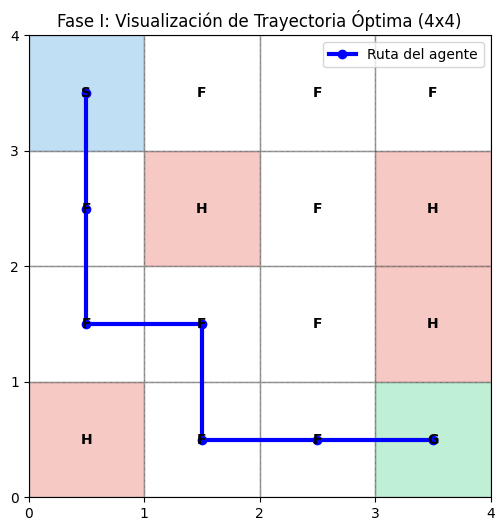

In [12]:
def graficar_trayectoria_4x4(trayectoria):
    mapa_bytes = entorno.unwrapped.desc
    mapa = [[celda.decode('utf-8') for celda in fila] for fila in mapa_bytes]
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 2. Dibujar el tablero
    for r in range(4):
        for c in range(4):
            celda = mapa[r][c]
            # Color base para celdas
            color = 'white'
            if celda == 'H': color = '#e74c3c' # Rojo para hoyos
            if celda == 'G': color = '#2ecc71' # Verde para meta
            if celda == 'S': color = '#3498db' # Azul para inicio
            
            # Dibujar el cuadrado de la celda
            rect = plt.Rectangle((c, 3-r), 1, 1, facecolor=color, edgecolor='black', alpha=0.3)
            ax.add_patch(rect)
            # Agregar el texto (S, G, H)
            ax.text(c + 0.5, 3 - r + 0.5, celda, va='center', ha='center', fontweight='bold')

    # 3. Trazar la trayectoria del agente
    # Convertimos los índices de estado (0-15) a coordenadas (x, y)
    x_coords = [s % 4 + 0.5 for s in trayectoria]
    y_coords = [3 - (s // 4) + 0.5 for s in trayectoria]
    
    # Dibujar línea y puntos de paso
    ax.plot(x_coords, y_coords, color='blue', marker='o', linewidth=3, label='Ruta del agente')
    
    # 4. Ajustes finales de la gráfica
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title("Fase I: Visualización de Trayectoria Óptima (4x4)")
    ax.legend(loc='upper right')
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# Llamada a la función usando la trayectoria del paso anterior
graficar_trayectoria_4x4(trayectoria_final)

___
## Fase 2: Experimento a 8x8

### **2.1 Entrenamiento:** Ajuste los hiperparámetros (tasa de aprendizaje, factor de descuento, épsilon y total de episodios) para garantizar que el agente aprenda a llegar a la meta.



In [13]:
# Mapa fijo para reproducibilidad con más hoyos
mapa_8x8 = generate_random_map(size=8, p=0.60, seed=42)
entorno_8x8 = gym.make('FrozenLake-v1', desc=mapa_8x8, is_slippery=False)

print('Mapa 8x8 usado:')
for fila in mapa_8x8:
    print(fila)

# Inicialización de la Matriz Q para 64 estados y 4 acciones
no_estados_8x8 = entorno_8x8.observation_space.n
no_acciones_8x8 = entorno_8x8.action_space.n
matriz_Q_8x8 = np.zeros((no_estados_8x8, no_acciones_8x8))

# Hiperparámetros ajustados para 8x8
tasa_aprendizaje_8 = 0.2
factor_descuento_8 = 0.99
epsilon_8 = 1.0
max_episodios_8 = 50000
max_pasos_por_episodio_8 = 200
min_epsilon_8 = 0.05
epsilon_decay_rate_8 = (epsilon_8 - min_epsilon_8) / max_episodios_8

Mapa 8x8 usado:
SFFFFFFF
HFFFFHFH
HFHFFFHF
FFFHFFFH
FFFHHHFH
HHFFFHFF
FFFHHHFH
FHFFFFFG


### **2.2 Reporte de hiperparámetros:** Documente en una celda de texto los valores elegidos y justifique por qué son diferentes (o iguales) a los del mapa 4x4

### 2.2 Reporte de hiperparámetros (8x8)

En el mapa **8x8** se usaron hiperparámetros diferentes a 4x4 porque el problema es más grande, tiene más estados (64 vs 16), trayectorias más largas y mayor riesgo de caer en hoyos. Por eso el agente necesita explorar más y aprender de forma más estable.

- **`tasa_aprendizaje_8 = 0.2`**  
    Se redujo respecto a 4x4 (`0.8`) para evitar actualizaciones bruscas de la Q-table. En 8x8 hay más variabilidad y una tasa menor estabiliza el aprendizaje.

- **`factor_descuento_8 = 0.99`**  
    Se incrementó respecto a 4x4 (`0.8`) porque la meta suele estar más lejos. Un descuento alto da más peso a recompensas futuras y favorece rutas largas correctas.

- **`epsilon_8 = 1.0`** y **`min_epsilon_8 = 0.05`**  
    Se inicia con exploración total para cubrir mejor el espacio de estados y se mantiene una exploración mínima para no quedar atrapado en políticas subóptimas.

- **`max_episodios_8 = 50000`**  
    Se aumentó considerablemente (vs `5000`) porque en 8x8 el agente requiere más experiencia para converger a una política robusta.

- **`max_pasos_por_episodio_8 = 200`**  
    Se elevó (vs `100`) para permitir que el agente complete trayectorias más largas sin cortar episodios prematuramente.

- **`epsilon_decay_rate_8 = (1.0 - 0.05) / 50000`**  
    El decaimiento es más lento para mantener exploración durante más episodios, lo cual es clave en un entorno más complejo.

En conjunto, estos ajustes equilibran **exploración amplia**, **aprendizaje estable** y **planificación de largo plazo**, necesarios para lograr alta tasa de éxito en 8x8.

In [14]:
# Recompensas por episodio para 8x8
recompensa_por_episodio_8 = []
exitos_entrenamiento_8 = 0

# Definición del ciclo de entrenamiento (8x8)
for episodio in range(max_episodios_8):
    # Resetear el entorno 8x8
    estado, info = entorno_8x8.reset()
    terminado = False
    inconcluso = False
    recompensa_actual = 0

    for paso in range(max_pasos_por_episodio_8):
      # 1. Elección de la acción
      if random.uniform(0, 1) < epsilon_8:
        accion = entorno_8x8.action_space.sample()  # Acción aleatoria
      else:
        accion = np.argmax(matriz_Q_8x8[estado, :])  # Acción basada en la Q aprendida

      # 2. Ejecución de la acción y recepción de recompensa
      nuevo_estado, recompensa, terminado, inconcluso, info = entorno_8x8.step(accion)

      # Recompensa moldeada para acelerar aprendizaje en 8x8
      if recompensa == 1:
        recompensa_entrenamiento = 1.0
      elif terminado:
        recompensa_entrenamiento = -1.0
      else:
        recompensa_entrenamiento = -0.01

      # 3. Actualizar el valor de la función Q(s, a)
      matriz_Q_8x8[estado, accion] = matriz_Q_8x8[estado, accion] + tasa_aprendizaje_8 * (
          recompensa_entrenamiento + factor_descuento_8 * np.max(matriz_Q_8x8[nuevo_estado, :]) - matriz_Q_8x8[estado, accion]
      )
      estado = nuevo_estado
      recompensa_actual += recompensa

      if terminado or inconcluso:
        if recompensa > 0:
          exitos_entrenamiento_8 += 1
        break

    # Decremento de epsilon
    epsilon_8 = max(min_epsilon_8, epsilon_8 - epsilon_decay_rate_8)

    # Almacenamiento de recompensas
    recompensa_por_episodio_8.append(recompensa_actual)

    # Retroalimentación del avance
    if episodio % 5000 == 0:
      promedio_100 = np.mean(recompensa_por_episodio_8[-100:]) if len(recompensa_por_episodio_8) >= 1 else 0
      print(f'Episodio: {episodio}, recompensa promedio (ult.100): {promedio_100:.3f}, epsilon: {epsilon_8:.4f}, éxitos acumulados: {exitos_entrenamiento_8}')

print('Entrenamiento 8x8 terminado')
print(f'Éxitos durante entrenamiento: {exitos_entrenamiento_8}/{max_episodios_8}')

Episodio: 0, recompensa promedio (ult.100): 0.000, epsilon: 1.0000, éxitos acumulados: 0
Episodio: 5000, recompensa promedio (ult.100): 0.000, epsilon: 0.9050, éxitos acumulados: 0
Episodio: 10000, recompensa promedio (ult.100): 0.000, epsilon: 0.8100, éxitos acumulados: 1
Episodio: 15000, recompensa promedio (ult.100): 0.010, epsilon: 0.7150, éxitos acumulados: 13
Episodio: 20000, recompensa promedio (ult.100): 0.030, epsilon: 0.6200, éxitos acumulados: 54
Episodio: 25000, recompensa promedio (ult.100): 0.030, epsilon: 0.5250, éxitos acumulados: 181
Episodio: 30000, recompensa promedio (ult.100): 0.090, epsilon: 0.4300, éxitos acumulados: 466
Episodio: 35000, recompensa promedio (ult.100): 0.100, epsilon: 0.3350, éxitos acumulados: 1072
Episodio: 40000, recompensa promedio (ult.100): 0.380, epsilon: 0.2400, éxitos acumulados: 2324
Episodio: 45000, recompensa promedio (ult.100): 0.560, epsilon: 0.1450, éxitos acumulados: 4450
Entrenamiento 8x8 terminado
Éxitos durante entrenamiento: 77

### **2.3 Prueba:** Realice una evaluación de 100 episodios y reporte la tasa de éxito (success rate).

In [15]:
# --- EVALUACIÓN 8x8 USANDO LA FUNCIÓN PREVIA ---

episodios_prueba_8 = 100
exitos_8x8 = 0

print(f"Evaluando el desempeño del agente en 8x8...")

for _ in range(episodios_prueba_8):
    _, recompensa_total = ejecutar_episodio_greedy(entorno_8x8, matriz_Q_8x8)
    
    if recompensa_total > 0:
        exitos_8x8 += 1

tasa_exito_8x8 = (exitos_8x8 / episodios_prueba_8) * 100
print(f"Tasa de éxito del agente (8x8): {tasa_exito_8x8}%")

Evaluando el desempeño del agente en 8x8...
Tasa de éxito del agente (8x8): 100.0%


In [16]:
# Ejecución de la prueba técnica
# Asegúrate de usar el entorno 8x8  
trayectoria_final, exito = ejecutar_episodio_greedy(entorno_8x8, matriz_Q_8x8)

print(f"¿Logró llegar a la meta?: {'Sí' if exito > 0 else 'No'}")
print(f"Pasos seguidos (estados): {trayectoria_final}")

¿Logró llegar a la meta?: Sí
Pasos seguidos (estados): [0, 1, 9, 10, 11, 19, 20, 28, 29, 30, 38, 46, 54, 62, 63]


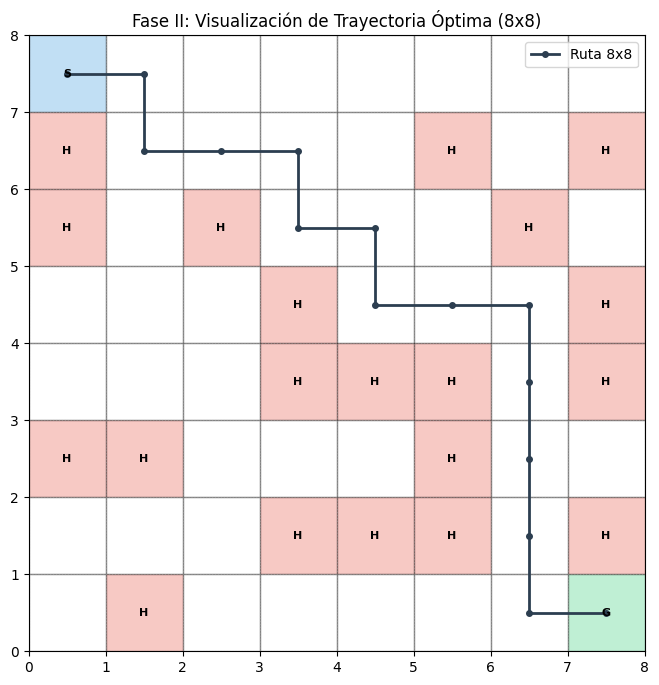

In [17]:
def graficar_trayectoria_8x8(trayectoria, entorno_8x8):
    mapa_bytes = entorno_8x8.unwrapped.desc
    mapa = [[celda.decode('utf-8') for celda in fila] for fila in mapa_bytes]
    size = 8  # Tamaño del mapa
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 2. Dibujar el tablero dinámicamente
    for r in range(size):
        for c in range(size):
            celda = mapa[r][c]
            
            # Lógica de colores basada en el tipo de celda
            color = 'white'
            if celda == 'H': color = '#e74c3c'  # Rojo (Hoyo)
            elif celda == 'G': color = '#2ecc71' # Verde (Meta)
            elif celda == 'S': color = '#3498db' # Azul (Inicio)
            
            # Dibujar el cuadrado (usamos size-1-r para invertir el eje Y correctamente)
            rect = plt.Rectangle((c, (size - 1) - r), 1, 1, facecolor=color, edgecolor='black', alpha=0.3)
            ax.add_patch(rect)
            
            # Opcional: Solo poner texto en celdas críticas para no saturar visualmente
            if celda in ['S', 'G', 'H']:
                ax.text(c + 0.5, (size - 1) - r + 0.5, celda, va='center', ha='center', fontweight='bold', fontsize=8)

    # 3. Trazar la trayectoria del agente
    # Convertimos los estados (0-63) a coordenadas (x, y)
    x_coords = [s % size + 0.5 for s in trayectoria]
    y_coords = [(size - 1) - (s // size) + 0.5 for s in trayectoria]
    
    # Dibujar la línea de la ruta
    ax.plot(x_coords, y_coords, color='#2c3e50', marker='o', markersize=4, linewidth=2, label='Ruta 8x8')
    
    # 4. Ajustes finales
    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_xticks(range(size + 1))
    ax.set_yticks(range(size + 1))
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_title("Fase II: Visualización de Trayectoria Óptima (8x8)")
    ax.legend(loc='upper right')
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# --- Ejecución ---
# 1. Obtenemos una trayectoria voraz del entrenamiento previo
trayectoria_8x8, _ = ejecutar_episodio_greedy(entorno_8x8, matriz_Q_8x8)

# 2. Graficamos
graficar_trayectoria_8x8(trayectoria_8x8, entorno_8x8)

___
## Fase 3: Experimento a 16x16

### **3.1 Entrenamiento:** Ajuste los hiperparámetros (tasa de aprendizaje, factor de descuento, épsilon y total de episodios) para garantizar que el agente aprenda a llegar a la meta.

In [18]:
# Mapa fijo para reproducibilidad con más hoyos
mapa_16x16 = generate_random_map(size=16, p=0.80, seed=42)
entorno_16x16 = gym.make('FrozenLake-v1', desc=mapa_16x16, is_slippery=False)

print('Mapa 16x16 usado:')
for fila in mapa_16x16:
    print(fila)

# Inicialización de la Matriz Q para 256 estados y 4 acciones
no_estados_16x16 = entorno_16x16.observation_space.n
no_acciones_16x16 = entorno_16x16.action_space.n
matriz_Q_16x16 = np.zeros((no_estados_16x16, no_acciones_16x16))

# Hiperparámetros ajustados para 16x16
tasa_aprendizaje_16 = 0.2
factor_descuento_16 = 0.99
epsilon_16 = 1.0
max_episodios_16 = 50000
max_pasos_por_episodio_16 = 200
min_epsilon_16 = 0.05
epsilon_decay_rate_16 = (epsilon_16 - min_epsilon_16) / max_episodios_16

Mapa 16x16 usado:
SFHFFHFFFFFHFHFF
FFHFFFHHFFFFFFFH
FFFFFFFFFHFFHHFF
FFFFFFFFFFFFFFFF
FFFFFFFFHFFFFFFF
FFHFFFFFFFFFFFFF
FFFHHFFHFFFFFHFF
FFFHFFFFFFFFFFFF
FFFHFFFFHFFFFFHF
FFFFFFHHFFFFFFFF
FHFFFFHHFHFFFHFF
FHHFHHFFFFFFFFHF
FHFFFHFFFHFFFFFF
FFFFFHFFFFHFFFFH
FHFFFFFFHFHHFFFF
HFFFFHFFFFFHFFFG


In [19]:
# Recompensas por episodio para 16x16
recompensa_por_episodio_16 = []
exitos_entrenamiento_16 = 0

# Definición del ciclo de entrenamiento (16x16)
for episodio in range(max_episodios_16):
    # Resetear el entorno 16x16
    estado, info = entorno_16x16.reset()
    terminado = False
    inconcluso = False
    recompensa_actual = 0

    for paso in range(max_pasos_por_episodio_16):
      # 1. Elección de la acción
      if random.uniform(0, 1) < epsilon_16:
        accion = entorno_16x16.action_space.sample()  # Acción aleatoria
      else:
        accion = np.argmax(matriz_Q_16x16[estado, :])  # Acción basada en la Q aprendida

      # 2. Ejecución de la acción y recepción de recompensa
      nuevo_estado, recompensa, terminado, inconcluso, info = entorno_16x16.step(accion)

      # Recompensa moldeada para acelerar aprendizaje en 16x16
      if recompensa == 1:
        recompensa_entrenamiento = 1.0
      elif terminado:
        recompensa_entrenamiento = -1.0
      else:
        recompensa_entrenamiento = -0.01

      # 3. Actualizar el valor de la función Q(s, a)
      matriz_Q_16x16[estado, accion] = matriz_Q_16x16[estado, accion] + tasa_aprendizaje_16 * (
          recompensa_entrenamiento + factor_descuento_16 * np.max(matriz_Q_16x16[nuevo_estado, :]) - matriz_Q_16x16[estado, accion]
      )
      estado = nuevo_estado
      recompensa_actual += recompensa

      if terminado or inconcluso:
        if recompensa > 0:
          exitos_entrenamiento_16 += 1
        break

    # Decremento de epsilon
    epsilon_16 = max(min_epsilon_16, epsilon_16 - epsilon_decay_rate_16)

    # Almacenamiento de recompensas
    recompensa_por_episodio_16.append(recompensa_actual)

    # Retroalimentación del avance
    if episodio % 5000 == 0:
      promedio_100 = np.mean(recompensa_por_episodio_16[-100:]) if len(recompensa_por_episodio_16) >= 1 else 0
      print(f'Episodio: {episodio}, recompensa promedio (ult.100): {promedio_100:.3f}, epsilon: {epsilon_16:.4f}, éxitos acumulados: {exitos_entrenamiento_16}')

print('Entrenamiento 16x16 terminado')
print(f'Éxitos durante entrenamiento: {exitos_entrenamiento_16}/{max_episodios_16}')

Episodio: 0, recompensa promedio (ult.100): 0.000, epsilon: 1.0000, éxitos acumulados: 0
Episodio: 5000, recompensa promedio (ult.100): 0.000, epsilon: 0.9050, éxitos acumulados: 0
Episodio: 10000, recompensa promedio (ult.100): 0.000, epsilon: 0.8100, éxitos acumulados: 0
Episodio: 15000, recompensa promedio (ult.100): 0.000, epsilon: 0.7150, éxitos acumulados: 0
Episodio: 20000, recompensa promedio (ult.100): 0.000, epsilon: 0.6200, éxitos acumulados: 1
Episodio: 25000, recompensa promedio (ult.100): 0.040, epsilon: 0.5250, éxitos acumulados: 45
Episodio: 30000, recompensa promedio (ult.100): 0.110, epsilon: 0.4300, éxitos acumulados: 674
Episodio: 35000, recompensa promedio (ult.100): 0.260, epsilon: 0.3350, éxitos acumulados: 1515
Episodio: 40000, recompensa promedio (ult.100): 0.310, epsilon: 0.2400, éxitos acumulados: 2751
Episodio: 45000, recompensa promedio (ult.100): 0.430, epsilon: 0.1450, éxitos acumulados: 4814
Entrenamiento 16x16 terminado
Éxitos durante entrenamiento: 812

### **3.2 Prueba:** Realice una evaluación de 100 episodios y reporte la tasa de éxito (success rate).

In [20]:
# --- EVALUACIÓN 16x16 USANDO LA FUNCIÓN PREVIA ---

episodios_prueba_16 = 100
exitos_16x16 = 0

print(f"Evaluando el desempeño del agente en 16x16...")

for _ in range(episodios_prueba_16):
    _, recompensa_total = ejecutar_episodio_greedy(entorno_16x16, matriz_Q_16x16)
    
    if recompensa_total > 0:
        exitos_16x16 += 1

tasa_exito_16x16 = (exitos_16x16 / episodios_prueba_16) * 100
print(f"Tasa de éxito del agente (16x16): {tasa_exito_16x16}%")

Evaluando el desempeño del agente en 16x16...
Tasa de éxito del agente (16x16): 100.0%


In [21]:
# Ejecución de la prueba técnica
# Asegúrate de usar el entorno 16x16  
trayectoria_final, exito = ejecutar_episodio_greedy(entorno_16x16, matriz_Q_16x16)

print(f"¿Logró llegar a la meta?: {'Sí' if exito > 0 else 'No'}")
print(f"Pasos seguidos (estados): {trayectoria_final}")

¿Logró llegar a la meta?: Sí
Pasos seguidos (estados): [0, 16, 32, 48, 64, 65, 66, 67, 83, 84, 85, 101, 117, 118, 119, 120, 121, 137, 153, 154, 170, 186, 202, 203, 219, 220, 236, 252, 253, 254, 255]


In [22]:
def graficar_trayectoria_16x16(trayectoria, entorno_16):
    # 1. Extracción del mapa del entorno (funciona igual para cualquier tamaño)
    mapa_bytes = entorno_16.unwrapped.desc
    mapa = [[celda.decode('utf-8') for celda in fila] for fila in mapa_bytes]
    size = 16  # Escalamos a 16
    
    # Aumentamos el tamaño de la figura para mantener la resolución de los detalles
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 2. Dibujar el tablero
    for r in range(size):
        for c in range(size):
            celda = mapa[r][c]
            
            color = 'white'
            if celda == 'H': color = '#e74c3c'  # Hoyo
            elif celda == 'G': color = '#2ecc71' # Meta
            elif celda == 'S': color = '#3498db' # Inicio
            
            # Dibujar celda
            rect = plt.Rectangle((c, (size - 1) - r), 1, 1, facecolor=color, edgecolor='black', alpha=0.3)
            ax.add_patch(rect)
            
            # Ajustamos el tamaño de fuente para el mapa de 16x16
            if celda in ['S', 'G', 'H']:
                ax.text(c + 0.5, (size - 1) - r + 0.5, celda, 
                        va='center', ha='center', fontweight='bold', fontsize=6)

    # 3. Trazar la trayectoria
    # La lógica de conversión de estado (0-255) a coordenadas (x, y) es automática con 'size'
    x_coords = [s % size + 0.5 for s in trayectoria]
    y_coords = [(size - 1) - (s // size) + 0.5 for s in trayectoria]
    
    # Usamos una línea más delgada y marcadores más pequeños para no tapar el mapa
    ax.plot(x_coords, y_coords, color='#2c3e50', marker='o', markersize=2, linewidth=1.5, label='Ruta 16x16')
    
    # 4. Ajustes finales
    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    # Mostramos los ticks pero con etiquetas más pequeñas
    ax.set_xticks(range(size + 1))
    ax.set_yticks(range(size + 1))
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_title("Fase III: Visualización de Trayectoria Óptima (16x16)")
    ax.legend(loc='upper right', fontsize='small')
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

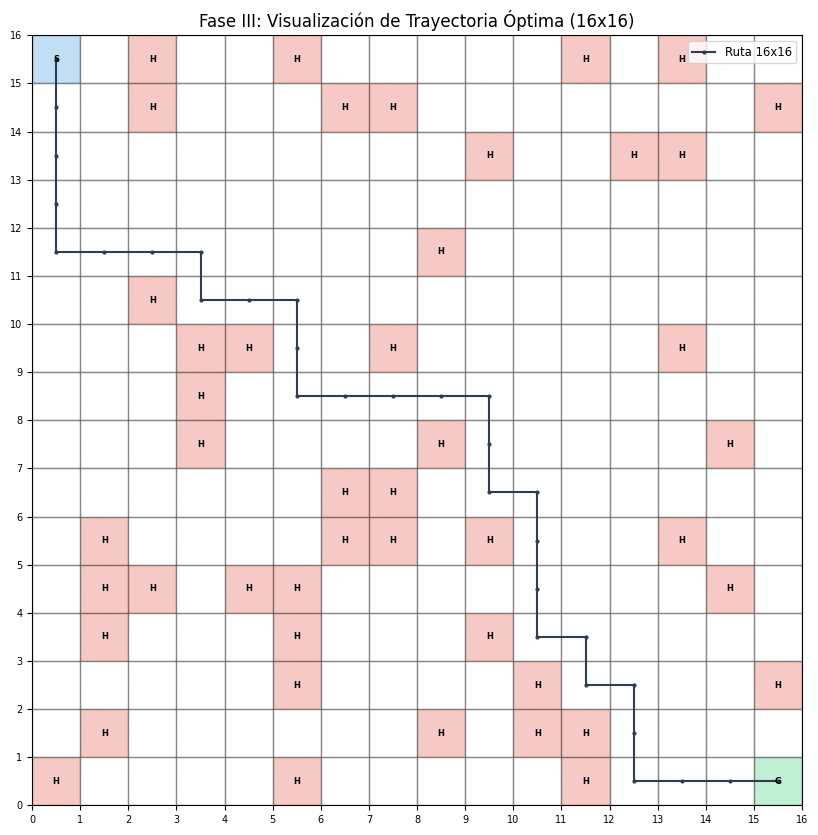

In [23]:
# 1. Obtenemos una trayectoria voraz del entrenamiento previo
trayectoria_16, _ = ejecutar_episodio_greedy(entorno_16x16, matriz_Q_16x16)

# 2. Graficamos
graficar_trayectoria_16x16(trayectoria_16, entorno_16x16)

**Conclución:**
El escalamiento de un entorno de Aprendizaje por Refuerzo, como la transición de un mapa de 4x4 (16 estados) a uno de 16x16 (256 estados), no representa un incremento lineal en la dificultad, sino una progresión exponencial que pone a prueba la robustez del algoritmo Q-Learning. 

Durante esta actividad, se identificaron tres pilares críticos: la explosión del espacio de estados, el tiempo de convergencia y el problema de las recompensas dispersas.
1. **Explosión del espacio de estados**  
En un mapa de 4x4 el agente maneja 64 valores; al subir a 16x16 eso escala a 1,024. Aquí pega la famosa maldición de la dimensionalidad: el agente casi no vuelve a caer en el mismo estado durante la exploración, así que aprender la matriz Q se vuelve mucho más lento y menos estable.

2. **Tiempo de convergencia**  
En un grid de 16x16, el camino a la meta es más largo. Eso hace que el error TD tenga que propagarse a través de muchos más estados intermedios. Para que esto no se vuelva inestable, hay que bajar la tasa de aprendizaje ($\alpha$) y subir el factor de descuento ($\gamma$) (≈0.95 o más), para que la recompensa final siga “pesando” aunque esté lejos.

3. **Recompensas dispersas (sparse rewards)**  
Aquí está el verdadero problema: casi no hay retroalimentación. Si solo hay un +1 al llegar a la meta, en 256 celdas encontrarla al azar es muy poco probable. Si no mantienes una exploración ($\epsilon$) suficientemente alta y con decaimiento lento, el agente puede simplemente no encontrar nunca la meta. En estos casos por cuestiones de mera fortuna creo yo funcionaron los mismos hiperparametros del 8x8 para el 16x16 cosa que al pasar del 4x4 al 8x8 no se pudo hacer ya que no entrenaba bien.
    